In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from transformers import AutoTokenizer, MPNetModel
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, cohen_kappa_score
from scipy.stats import pearsonr

from tqdm import tqdm

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 16
EPOCHS = 10
PATIENCE = 3
LEARNING_RATE = 2e-5
MAX_LENGTH = 512
RANDOM_SEED = 42
WARMUP_RATIO = 0.1

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Device:", DEVICE)

Device: cuda


In [3]:
df = pd.read_csv(
    "task2_cleaned_final.csv",
    engine="python",
    on_bad_lines="skip"
)
df

criteria_cols = [
    "Task_Response",
    "Coherence_Cohesion",
    "Lexical_Resource",
    "Range_Accuracy"
]

features = [
    "length",
    "unique_words",
    "ttr",
    "avg_word_len",
    "sentence_count",
    "avg_sentence_len",
    "sentence_len_var",
    "long_word_ratio",
    "short_word_ratio",
    "punct_density",
]

df = df.dropna(subset=criteria_cols + ["Essay"]).reset_index(drop=True)

print("Total essays:", len(df))

Total essays: 8748


In [4]:
df[criteria_cols] = df[criteria_cols] / 9.0

criteria = torch.tensor(df[criteria_cols].values, dtype=torch.float32)


criteria

tensor([[0.6667, 0.6667, 0.6667, 0.6667],
        [0.8889, 0.8889, 0.8889, 0.8889],
        [1.0000, 1.0000, 1.0000, 1.0000],
        ...,
        [0.6667, 0.6667, 0.6667, 0.6667],
        [0.6667, 0.6667, 0.6667, 0.6667],
        [0.6667, 0.6667, 0.6667, 0.6667]])

In [5]:
tokenizer = AutoTokenizer.from_pretrained("microsoft/mpnet-base")

texts = [
    str(q).strip() + " </s> </s> " + str(e).strip()
    for q, e in zip(df["Question"], df["Essay"])
]

encoded = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)
input_ids = encoded["input_ids"]
attention_mask = encoded["attention_mask"]



config.json:   0%|          | 0.00/493 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:
idx = np.arange(len(df))

train_idx, temp_idx = train_test_split(
    idx,
    test_size=0.3,
    random_state=RANDOM_SEED,
    shuffle=True
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=2/3,
    random_state=RANDOM_SEED
)

print(len(train_idx), len(val_idx), len(test_idx))

6123 875 1750


In [7]:
scaler = StandardScaler()
df[features] = df[features].astype(float)

df_features = df[features].copy()

df.loc[train_idx, features] = scaler.fit_transform(df.loc[train_idx, features])
df.loc[val_idx, features] = scaler.transform(df.loc[val_idx, features])
df.loc[test_idx, features] = scaler.transform(df.loc[test_idx, features])

feat_tensor = torch.tensor(df[features].values, dtype=torch.float32)

In [8]:
train_dataset = TensorDataset(
    input_ids[train_idx],
    attention_mask[train_idx],
    criteria[train_idx],
    feat_tensor[train_idx]
)

val_dataset = TensorDataset(
    input_ids[val_idx],
    attention_mask[val_idx],
    criteria[val_idx],
    feat_tensor[val_idx]
)

test_dataset = TensorDataset(
    input_ids[test_idx],
    attention_mask[test_idx],
    criteria[test_idx],
    feat_tensor[test_idx]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [9]:
class MPNetIELTS(nn.Module):
    def __init__(self, feature_dim):
        super().__init__()

        self.mpnet = MPNetModel.from_pretrained("microsoft/mpnet-base")
        hidden_size = self.mpnet.config.hidden_size

        self.feature_encoder = nn.Sequential(
            nn.LayerNorm(feature_dim),
            nn.Linear(feature_dim, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.GELU()
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2 + 64, 512),   # mean + max + feat
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.4)
        )

        self.head_tr = nn.Sequential(
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
        self.head_cc = nn.Sequential(
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
        self.head_lr = nn.Sequential(
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
        self.head_ga = nn.Sequential(
            nn.Linear(256, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def mean_pooling(self, last_hidden, mask):
        mask_expanded = mask.unsqueeze(-1).expand(last_hidden.size()).float()
        sum_hidden = torch.sum(last_hidden * mask_expanded, dim=1)
        sum_mask = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
        return sum_hidden / sum_mask

    def max_pooling(self, last_hidden, mask):
        mask_expanded = mask.unsqueeze(-1).expand(last_hidden.size()).float()
        masked_hidden = last_hidden.masked_fill(mask_expanded == 0, -1e9)
        return torch.max(masked_hidden, dim=1).values

    def forward(self, ids, mask, features):
        outputs = self.mpnet(ids, attention_mask=mask)
        last_hidden = outputs.last_hidden_state

        mean_embed = self.mean_pooling(last_hidden, mask)
        max_embed = self.max_pooling(last_hidden, mask)
        text_embed = torch.cat([mean_embed, max_embed], dim=1)

        feat_embed = self.feature_encoder(features)

        x = torch.cat([text_embed, feat_embed], dim=1)
        x = self.fc(x)

        tr = self.head_tr(x)
        cc = self.head_cc(x)
        lr = self.head_lr(x)
        ga = self.head_ga(x)

        crit = torch.cat([tr, cc, lr, ga], dim=1)
        return crit

In [10]:
def freeze_mpnet(model):
    for param in model.mpnet.parameters():
        param.requires_grad = False

def unfreeze_last_n_layers(model, n_last=2):
    for param in model.mpnet.parameters():
        param.requires_grad = False

    for layer in model.mpnet.encoder.layer[-n_last:]:
        for param in layer.parameters():
            param.requires_grad = True

def build_optimizer(model, encoder_lr, head_lr):
    encoder_params = []
    head_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue

        if name.startswith("mpnet"):
            encoder_params.append(param)
        else:
            head_params.append(param)

    param_groups = []

    if len(encoder_params) > 0:
        param_groups.append({
            "params": encoder_params,
            "lr": encoder_lr,
            "weight_decay": 0.01
        })

    if len(head_params) > 0:
        param_groups.append({
            "params": head_params,
            "lr": head_lr,
            "weight_decay": 0.01
        })

    return AdamW(param_groups)

In [11]:
def compute_loss(pred, target, beta=0.05):
    # pred, target: [B, 4], normalized [0,1]
    pred_overall = pred.mean(dim=1)
    true_overall = target.mean(dim=1)

    loss_crit = F.smooth_l1_loss(pred, target, beta=beta)
    loss_overall = F.l1_loss(pred_overall, true_overall)

    loss = 0.7 * loss_crit + 0.3 * loss_overall
    return loss


In [12]:
model = MPNetIELTS(feature_dim=feat_tensor.shape[1]).to(DEVICE)

freeze_mpnet(model)

optimizer = build_optimizer(
    model,
    encoder_lr=1e-5,
    head_lr=LEARNING_RATE
)

model.safetensors:   0%|          | 0.00/532M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: microsoft/mpnet-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.decoder.bias      | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(WARMUP_RATIO * total_steps),
    num_training_steps=total_steps
)

In [14]:
best_val = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

logs = []

In [15]:
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    if epoch == 1:
        print("Unfreeze last 2 layers")
        unfreeze_last_n_layers(model, n_last=2)

        optimizer = build_optimizer(
            model,
            encoder_lr=8e-6,
            head_lr=3e-5
        )

        remaining_steps = len(train_loader) * (EPOCHS - epoch)

        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=int(WARMUP_RATIO * remaining_steps),
            num_training_steps=remaining_steps
        )

    elif epoch == 4:
        print("Unfreeze last 4 layers")
        unfreeze_last_n_layers(model, n_last=4)

        optimizer = build_optimizer(
            model,
            encoder_lr=5e-6,
            head_lr=2e-5
        )

        remaining_steps = len(train_loader) * (EPOCHS - epoch)

        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=int(WARMUP_RATIO * remaining_steps),
            num_training_steps=remaining_steps
        )

    model.train()
    train_loss = 0.0

    for ids, mask, crit, feat in tqdm(train_loader):
        ids = ids.to(DEVICE)
        mask = mask.to(DEVICE)
        crit = crit.to(DEVICE)
        feat = feat.to(DEVICE)

        optimizer.zero_grad()

        pred = model(ids, mask, feat)

        loss = compute_loss(pred, crit, beta=0.05)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

    avg_train = train_loss / len(train_loader)

    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for ids, mask, crit, feat in val_loader:
            ids = ids.to(DEVICE)
            mask = mask.to(DEVICE)
            crit = crit.to(DEVICE)
            feat = feat.to(DEVICE)

            pred = model(ids, mask, feat)

            loss = compute_loss(pred, crit, beta=0.05)

            val_loss += loss.item()

    avg_val = val_loss / len(val_loader)

    print(f"Train Loss: {avg_train}")
    print(f"Val Loss:   {avg_val}")

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    logs.append({
        "epoch": epoch + 1,
        "train_loss": avg_train,
        "val_loss": avg_val
    })

    if avg_val < best_val:
        best_val = avg_val
        patience_counter = 0

        torch.save(model.state_dict(), "mpnet_model.pt")

        print("Saved best model")

    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping")
            break


Epoch 1/10


100%|██████████| 383/383 [00:42<00:00,  9.09it/s]


Train Loss: 0.3017156846801855
Val Loss:   0.12985916584730148
Saved best model

Epoch 2/10
Unfreeze last 2 layers


100%|██████████| 383/383 [00:41<00:00,  9.14it/s]


Train Loss: 0.13621279476672488
Val Loss:   0.09559961191632531
Saved best model

Epoch 3/10


...

Train Loss: 0.09305689730936803
Val Loss:   0.07854025783863934
Saved best model

Epoch 9/10


100%|██████████| 383/383 [00:49<00:00,  7.77it/s]


Train Loss: 0.09215137389714662
Val Loss:   0.08040078681978312

Epoch 10/10


100%|██████████| 383/383 [00:55<00:00,  6.88it/s]


Train Loss: 0.09145246021079954
Val Loss:   0.07977238581939176


In [16]:
log_df = pd.DataFrame(logs)

log_df.to_csv(
    "mpnet.csv",
    index=False
)

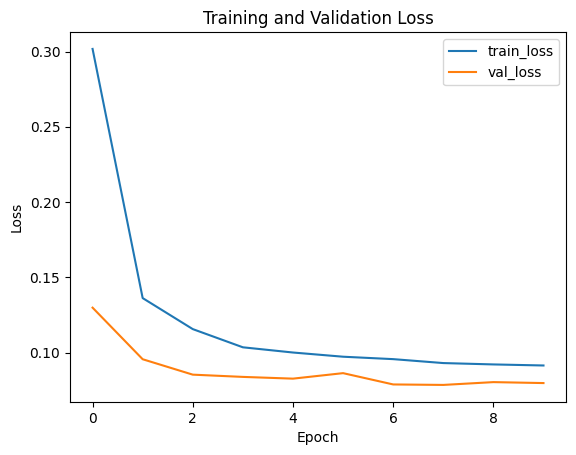

In [17]:
plt.plot(train_losses, label="train_loss")
plt.plot(val_losses, label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [18]:
model.load_state_dict(torch.load("mpnet_model.pt", map_location=DEVICE))
model.eval()

MPNetIELTS(
  (mpnet): MPNetModel(
    (embeddings): MPNetEmbeddings(
      (word_embeddings): Embedding(30527, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): MPNetEncoder(
      (layer): ModuleList(
        (0-11): 12 x MPNetLayer(
          (attention): MPNetAttention(
            (attn): MPNetSelfAttention(
              (q): Linear(in_features=768, out_features=768, bias=True)
              (k): Linear(in_features=768, out_features=768, bias=True)
              (v): Linear(in_features=768, out_features=768, bias=True)
              (o): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
         

In [19]:
preds = []
trues = []

model.eval()

with torch.no_grad():
    for ids, mask, crit, feat_batch in test_loader:
        ids = ids.to(DEVICE)
        mask = mask.to(DEVICE)
        feat_batch = feat_batch.to(DEVICE)

        crit_pred = model(ids, mask, feat_batch)

        preds.append(crit_pred.cpu().numpy())
        trues.append(crit.cpu().numpy())

pred = np.vstack(preds)
true = np.vstack(trues)

pred = np.clip(pred, 0.0, 1.0) * 9.0
true = true * 9.0

pred_overall = pred.mean(axis=1)
true_overall = true.mean(axis=1)

In [20]:
mae = mean_absolute_error(true_overall, pred_overall)

rmse = np.sqrt(mean_squared_error(true_overall, pred_overall))

pearson = pearsonr(true_overall, pred_overall)[0]

rounded_preds = np.round(pred_overall * 2) / 2
within_half = np.mean(np.abs(rounded_preds - true_overall) <= 0.5)

true_band = np.round(true_overall * 2).astype(int)
pred_band = np.round(pred_overall * 2).astype(int)

qwk = cohen_kappa_score(true_band, pred_band, weights="quadratic")

print("\nTEST RESULTS")
print("MAE:", mae)
print("RMSE:", rmse)
print("Pearson:", pearson)
print("Within ±0.5:", within_half)
print("QWK:", qwk)


TEST RESULTS
MAE: 0.8156011700630188
RMSE: 1.0815578485502948
Pearson: 0.48738584
Within ±0.5: 0.5011428571428571
QWK: 0.3642358187469896


In [21]:
def ielts_round(score):

    integer = int(score)
    decimal = score - integer

    if decimal < 0.25:
        return integer
    elif decimal <= 0.5:
        return integer + 0.5
    elif decimal < 0.75:
        return integer + 0.5
    else:
        return integer + 1

In [22]:
def predict_score_task2(question, essay):
    model.eval()

    text = essay.lower()

    tokens = re.findall(r'\b\w+\b', text)
    word_count = len(tokens)
    unique_words = len(set(tokens))
    ttr = unique_words / word_count if word_count > 0 else 0

    avg_word_len = np.mean([len(w) for w in tokens]) if word_count > 0 else 0

    sentences = re.split(r'[.!?]+', essay)
    sentences = [s for s in sentences if s.strip() != ""]

    sentence_count = len(sentences)
    avg_sentence_len = word_count / sentence_count if sentence_count > 0 else 0
    sentence_len_var = np.var([len(s.split()) for s in sentences]) if sentence_count > 0 else 0

    long_word_ratio = np.mean([len(w) > 6 for w in tokens]) if word_count > 0 else 0
    short_word_ratio = np.mean([len(w) <= 3 for w in tokens]) if word_count > 0 else 0

    punct_count = len(re.findall(r'[,.!?;:]', essay))
    punct_density = punct_count / word_count if word_count > 0 else 0

    feature_vector = [[
        word_count,
        unique_words,
        ttr,
        avg_word_len,
        sentence_count,
        avg_sentence_len,
        sentence_len_var,
        long_word_ratio,
        short_word_ratio,
        punct_density
    ]]

    feature_vector = scaler.transform(feature_vector)
    feat_tensor = torch.tensor(feature_vector, dtype=torch.float32).to(DEVICE)

    encoded = tokenizer(
        [str(question)],
        [str(essay)],
        padding=True,
        truncation="only_second",
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )

    ids = encoded["input_ids"].to(DEVICE)
    mask = encoded["attention_mask"].to(DEVICE)

    with torch.no_grad():
        crit = model(ids, mask, feat_tensor)

    crit = crit.squeeze(0).cpu().numpy()

    # vì output đang là linear, nên clamp trước khi scale về 0-9
    crit = np.clip(crit, 0.0, 1.0) * 9.0
    overall = np.mean(crit)

    return {
        "Task_Response": float(crit[0]),
        "Coherence_Cohesion": float(crit[1]),
        "Lexical_Resource": float(crit[2]),
        "Range_Accuracy": float(crit[3]),
        "Overall": float(ielts_round(overall))
    }

In [23]:
question = "The availability of unhealthy food, such as fast food and junk food, has become more widespread in recent years. What are some of the problems associated with this development and what action can be taken to solve them?"

essay = """
In the past two decades, there has been a significant change in eating habits with a shift to more unhealthy convenience foods that can be consumed on the go.  Although this has resulted in some negative consequences, it is possible to mitigate them if governments and citizens take action together.

The increase in the consumption of fast food has led to serious health effects in today’s society.  The first problem is that many people no longer have time to prepare and sit down to healthily cooked meals, so instead turn to fast food, which has led to soaring obesity rates. In addition, it is cited that unhealthy foods are substantially cheaper and are therefore consumed in greater volume by the working classes as opposed to more expensive fresh foods such as fish, fruit and vegetables.  A third issue is that the unhealthy chemicals and preservatives in processed foods have been directly attributed to causing fatal health issues such as cardiovascular disease and cancer.

There are several measures that governments could take to lessen the impact of the aforementioned problems.  Regarding the time constraints of society, laws to restrict employee working hours and the enforcement of longer lunch breaks could encourage people to change their eating habits. To address cost issues, governments could implement higher taxation levies on unhealthy foods and use the revenues generated to subsidize fresh foods for working class families.  Governments should also directly address the production methods of mass processed foods with the manufacturers and implement tougher restrictions on the use of harmful preservatives.

In conclusion, a range of measures can be taken to combat the health issues related to consuming unhealthy food.  If such actions are not implemented, it is likely that these problems will become more prevalent and lead to a greater number of unnecessary deaths.
"""

result8 = predict_score_task2(question, essay)

for k, v in result8.items():
    print(k, ":", v)


/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Task_Response : 7.324943542480469
Coherence_Cohesion : 7.322551727294922
Lexical_Resource : 6.825232028961182
Range_Accuracy : 6.93388557434082
Overall : 7.0


In [24]:
question = " Some people think that competition at work, at school and in daily life is a good thing. Others believe that we should try to cooperate more, rather than competing against each other. Discuss both these views and give your own opinion."

essay = """
In my opinion competition at work, at school and in daily life can both be a good thing and a bad thing. Why? because I think too much of anything can be destructive. Yes, it’s a very good thing to be competitive but don’t overdo it! Having no competition in your life at all can be very depressing, because you have no motivation, no goals you want to achieve, everytime you wake up in the morning. I don’t believe that there is such thing as “co-operating” too much, when you work with someone you should work together as a team and co-operate, but also do things for yourself, like something career-wise. You should think of your future in your work. That goes the same if you are still in school, take my school life for example. If I am very good at one subject in particular, lots of other student may come up to me and ask for pointers. I would be very glad to help them. If there is any homework, school mates may come over to do it together. this is also fine and very good for building relationship. But sometimes there are people who think you are so nice and ask you to do their work for them. This is where you should draw the line, yes you are friends and you should help each other, but that doesn’t mean that you have to do their homework or give them answer when there is a test. Remember life is a competition, be a winner."""

result6 = predict_score_task2(question, essay)

for k, v in result6.items():
    print(k, ":", v)


Task_Response : 6.532506465911865
Coherence_Cohesion : 6.434378147125244
Lexical_Resource : 5.971079349517822
Range_Accuracy : 6.1324920654296875
Overall : 6.5


/venv/main/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


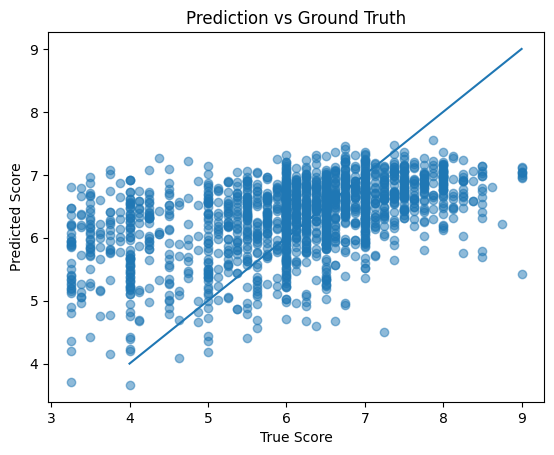

In [25]:
plt.scatter(true_overall, pred_overall, alpha=0.5)
plt.plot([4,9], [4,9])  

plt.xlabel("True Score")
plt.ylabel("Predicted Score")
plt.title("Prediction vs Ground Truth")
plt.show()

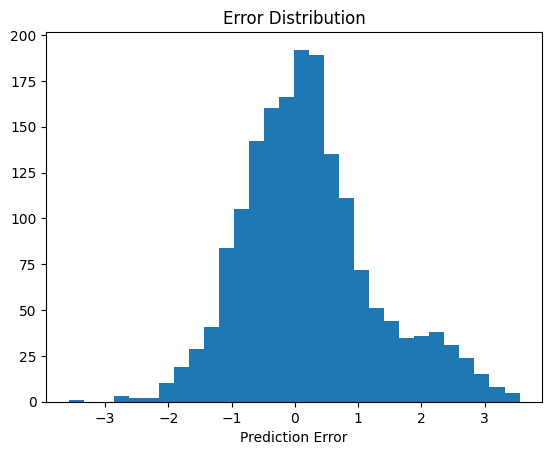

In [26]:
errors = pred_overall - true_overall

plt.hist(errors, bins=30)
plt.title("Error Distribution")
plt.xlabel("Prediction Error")
plt.show()